In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fase 3 da pós em engenharia de machine learning

O objetivo dessa fase é realizar dois modelos, um supervisionado e outro não-supervisionada usando para isso a base de cancelamento e atraso de voos nos EUA.

Usaremos:
- XGBoost e LGBM para classificação
- Kmeans para clusterização
- PCA para redução de dimensionalidade

## Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")



## Carregamento das bases

In [ ]:
try:
    airlines = pd.read_csv('./drive/MyDrive/POSFIAP/airlines.csv')
    print("CSV file loaded successfully!")
    print(airlines.head())
except FileNotFoundError:
    print("Error: The file '/airlines.csv' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
try:
    airports = pd.read_csv('./drive/MyDrive/POSFIAP/airports.csv')
    print("CSV file loaded successfully!")
    print(airports.head())
except FileNotFoundError:
    print("Error: The file '/airports.csv' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

In [ ]:
try:
    flights = pd.read_csv('./drive/MyDrive/POSFIAP/flights.csv')
    print("CSV file loaded successfully!")
    print(flights.head())
except FileNotFoundError:
    print("Error: The file '/flights.csv' was not found.")
except Exception as e:
    print(f"An error occurred: {e}")

## Exploração dos dados (EDA)



In [ ]:
print("=" * 65)
print("VISÃO GERAL DO DATASET")
print("=" * 65)
print(f"  Shape             : {flights.shape[0]:,} linhas × {flights.shape[1]} colunas")
print()

In [ ]:
print("=" * 65)
print("TIPOS DE DADOS")
print("=" * 65)
print(flights.dtypes.to_string())

In [ ]:
print("Primeiras 5 linhas:")
flights.head()

In [ ]:
print("\n" + "=" * 65)
print("VALORES AUSENTES")
print("=" * 65)
missing = flights.isnull().sum()
missing_pct = (missing / len(flights) * 100).round(2)
missing_df = pd.DataFrame({"Ausentes": missing, "%": missing_pct})
missing_df = missing_df[missing_df["Ausentes"] > 0].sort_values("%", ascending=False)
missing_df

In [ ]:
print("\n" + "=" * 65)
print("ESTATÍSTICAS DESCRITIVAS — NUMÉRICAS")
print("=" * 65)
num_cols = ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "AIR_TIME", "DISTANCE",
            "TAXI_OUT", "TAXI_IN", "SCHEDULED_TIME", "ELAPSED_TIME",
            "WEATHER_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY",
            "AIR_SYSTEM_DELAY", "SECURITY_DELAY"]
num_cols = [c for c in num_cols if c in flights.columns]
flights[num_cols].describe().round(2)

In [ ]:
print("\n" + "=" * 65)
print("COLUNAS CATEGÓRICAS")
print("=" * 65)
cat_cols = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CANCELLATION_REASON"]
for col in cat_cols:
    if col in flights.columns:
        vc = flights[col].value_counts()
        print(f"\n{col} — {flights[col].nunique()} valores únicos")
        print(vc.head(15))


In [ ]:
print("\n" + "=" * 65)
print("CANCELAMENTOS E DESVIOS")
print("=" * 65)
if "CANCELLED" in flights.columns:
    cancelled = flights["CANCELLED"].sum()
    print(f"  Cancelados : {cancelled:,}  ({cancelled/len(flights)*100:.2f}%)")
if "DIVERTED" in flights.columns:
    diverted = flights["DIVERTED"].sum()
    print(f"  Desviados  : {diverted:,}  ({diverted/len(flights)*100:.2f}%)")

if "CANCELLATION_REASON" in flights.columns:
    cancelled_reason = flights["CANCELLATION_REASON"].isnull().sum()
    print(f"  Razão do cancelamento : {len(flights)-cancelled_reason:,}  ({100-cancelled_reason/len(flights)*100:.2f}%)")
    reason_map = {"A": "Airline", "B": "Weather", "C": "NAS", "D": "Security"}
    cr = flights["CANCELLATION_REASON"].dropna().map(reason_map).value_counts()
    print("\n Motivos de cancelamento:")
    print(cr.to_string())

In [ ]:
print("\n" + "=" * 65)
print("ANÁLISE DE ATRASOS")
print("=" * 65)
if "ARRIVAL_DELAY" in flights.columns:
    arr = flights["ARRIVAL_DELAY"].dropna()
    print(f"  Voos no horário (≤0 min) : {(arr <= 0).sum():,} ({(arr <= 0).mean()*100:.1f}%)")
    print(f"  15 min < Atraso <= 60 min: {((arr > 15) & (arr <= 60)).sum():,} ({((arr > 15) & (arr <= 60)).mean()*100:.1f}%)")
    print(f"  Atraso > 60 min          : {(arr > 60).sum():,} ({(arr > 60).mean()*100:.1f}%)")
    print(f"  Média ± desvio padrão    : {arr.mean():.1f} ± {arr.std():.1f} min")
    print(f"  Maior atraso registrado  : {arr.max():.0f} min")
    print(f"  Maior adiantamento       : {arr.min():.0f} min")

if "AIRLINE" in flights.columns and "ARRIVAL_DELAY" in flights.columns:
    print("\n Atraso médio por companhia (top 10):")
    atraso_airline = (flights.groupby("AIRLINE")["ARRIVAL_DELAY"]
                        .agg(["mean", "std", "count"])
                        .rename(columns={"mean": "Atraso_Médio", "std": "Desvio_Padrão", "count": "Voos"})
                        .sort_values("Atraso_Médio"))
    print(atraso_airline.round(2).to_string())

In [ ]:
print("\n" + "=" * 65)
print("CORRELAÇÕES PRINCIPAIS COM ARRIVAL_DELAY")
print("=" * 65)
if "ARRIVAL_DELAY" in flights.columns:
    corr_cols = [c for c in num_cols if c != "ARRIVAL_DELAY"]
    corr = flights[corr_cols + ["ARRIVAL_DELAY"]].corr()["ARRIVAL_DELAY"].drop("ARRIVAL_DELAY")
    print(corr.sort_values(ascending=False).round(3).to_string())

In [ ]:
month_map = {1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",
             7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"}
dow_map   = {1:"Seg",2:"Ter",3:"Qua",4:"Qui",5:"Sex",6:"Sáb",7:"Dom"}

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle("EDA — Dataset de Voos", fontsize=16, fontweight="bold", y=1.01)

# Distribuição de ARRIVAL_DELAY
ax = axes[0, 0]
if "ARRIVAL_DELAY" in flights.columns:
    data = flights["ARRIVAL_DELAY"].dropna().clip(-60, 200)
    ax.hist(data, bins=80, color="#4878CF", edgecolor="none", alpha=0.85)
    ax.axvline(0, color="#CC333F", lw=1.5, ls="--", label="Sem atraso")
    ax.set_title("Distribuição do atraso na chegada")
    ax.set_xlabel("Minutos")
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=9)

# Cancelamentos por motivo
ax = axes[0, 1]
if "CANCELLATION_REASON" in flights.columns:
    cr_data = flights["CANCELLATION_REASON"].dropna().map(reason_map).value_counts()
    bars = ax.barh(cr_data.index, cr_data.values, color=["#4878CF","#6ACC65","#D65F5F","#B47CC7"])
    ax.set_title("Cancelamentos por motivo")
    ax.set_xlabel("Quantidade")
    for bar, val in zip(bars, cr_data.values):
        ax.text(val + 10, bar.get_y() + bar.get_height()/2,
                f"{val:,}", va="center", fontsize=9)

# Atraso médio por companhia
ax = axes[0, 2]
if "AIRLINE" in flights.columns and "ARRIVAL_DELAY" in flights.columns:
    al_delay = (flights.groupby("AIRLINE")["ARRIVAL_DELAY"].mean()
                  .sort_values().dropna())
    colors = ["#D65F5F" if v > 0 else "#6ACC65" for v in al_delay.values]
    ax.barh(al_delay.index, al_delay.values, color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title("Atraso médio de chegada por companhia")
    ax.set_xlabel("Minutos")

# Mapa de calor — correlação
ax = axes[1, 0]
corr_matrix = flights[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            annot=True, fmt=".1f", annot_kws={"size": 7},
            linewidths=0.3, square=False)
ax.set_title("Correlação entre variáveis numéricas")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", labelsize=8)

# Atraso médio por mês
ax = axes[1, 1]
if "MONTH" in flights.columns and "ARRIVAL_DELAY" in flights.columns:
    monthly_vals = flights.groupby("MONTH")["ARRIVAL_DELAY"].mean()
    ax.plot(monthly_vals.index, monthly_vals.values, marker="o",
            color="#4878CF", lw=2)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(list(month_map.values()), fontsize=9)
    ax.set_title("Atraso médio de chegada por mês")
    ax.set_ylabel("Minutos")
    ax.axhline(monthly_vals.mean(), color="gray", ls="--", lw=1, label="Média geral")
    ax.legend(fontsize=9)

# Atraso médio por dia da semana
ax = axes[1, 2]
if "DAY_OF_WEEK" in flights.columns and "ARRIVAL_DELAY" in flights.columns:
    dow_vals = flights.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].mean()
    colors = ["#D65F5F" if v == dow_vals.max() else
              "#6ACC65" if v == dow_vals.min() else "#4878CF"
              for v in dow_vals.values]
    ax.bar(list(dow_map.values()), dow_vals.values, color=colors)
    ax.set_title("Atraso médio por dia da semana")
    ax.set_ylabel("Minutos")

# Distribuição DEPARTURE_DELAY vs ARRIVAL_DELAY (amostra)
ax = axes[2, 0]
if "DEPARTURE_DELAY" in flights.columns and "ARRIVAL_DELAY" in flights.columns:
    sample = flights[["DEPARTURE_DELAY", "ARRIVAL_DELAY"]].dropna().sample(
        min(5000, len(flights)), random_state=42)
    ax.scatter(sample["DEPARTURE_DELAY"].clip(-30, 150),
               sample["ARRIVAL_DELAY"].clip(-30, 150),
               alpha=0.15, s=5, color="#4878CF")
    ax.set_xlabel("Atraso na partida (min)")
    ax.set_ylabel("Atraso na chegada (min)")
    ax.set_title("Partida vs Chegada (amostra 5k)")
    ax.axhline(0, color="gray", lw=0.6, ls="--")
    ax.axvline(0, color="gray", lw=0.6, ls="--")

# Composição dos tipos de atraso
ax = axes[2, 1]
delay_cols = [c for c in ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
                           "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"] if c in flights.columns]
if delay_cols:
    delay_totals = flights[delay_cols].sum().sort_values(ascending=True)
    short_names  = [c.replace("_DELAY", "").replace("_", " ").title()
                    for c in delay_totals.index]
    ax.barh(short_names, delay_totals.values, color=sns.color_palette("muted", len(delay_cols)))
    ax.set_title("Total de minutos por tipo de atraso")
    ax.set_xlabel("Minutos totais")
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Top 10 rotas com maior atraso médio
ax = axes[2, 2]
if all(c in flights.columns for c in ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "ARRIVAL_DELAY"]):
    flights["ROUTE"] = flights["ORIGIN_AIRPORT"].astype(str) + "→" + flights["DESTINATION_AIRPORT"].astype(str)
    top_routes = (flights.groupby("ROUTE")["ARRIVAL_DELAY"]
                    .agg(["mean", "count"])
                    .query("count >= 200")
                    .nlargest(10, "mean"))
    ax.barh(top_routes.index, top_routes["mean"], color="#D65F5F")
    ax.set_title("Top 10 rotas com maior atraso médio\n(mín. 200 voos)")
    ax.set_xlabel("Minutos")

plt.tight_layout()
plt.savefig("eda_flights_plots.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n[OK] Gráfico salvo em eda_flights_plots.png")

In [ ]:
flights_delays = flights[flights["CANCELLED"] == 0].copy()

delay_cols = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
              "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
flights_delays[delay_cols] = flights_delays[delay_cols].fillna(0)

In [ ]:
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})
sns.set_palette("muted")

In [ ]:
# Helper: parsear HHMM → hora do dia
def hhmm_to_hour(series):
    s = series.dropna().astype(int).astype(str).str.zfill(4)
    return s.str[:2].astype(int)

In [ ]:
### sazonalidade

In [ ]:
print("\n" + "=" * 65)
print("ATRASO MÉDIO POR MÊS / DIA DA SEMANA")
print("=" * 65)

if "MONTH" in flights_delays.columns and "ARRIVAL_DELAY" in flights_delays.columns:
    print("\n  Por Mês:")
    monthly = (flights_delays.groupby("MONTH")["ARRIVAL_DELAY"].mean()
                 .rename(index=month_map).round(2))
    print(monthly.to_string())

if "DAY_OF_WEEK" in flights_delays.columns and "ARRIVAL_DELAY" in flights_delays.columns:
    print("\n  Por Dia da Semana:")
    dow = (flights_delays.groupby("DAY_OF_WEEK")["ARRIVAL_DELAY"].mean()
             .rename(index=dow_map).round(2))
    print(dow.to_string())

In [ ]:
print("=" * 65)
print("Atraso médio por hora de partida programada")
print("=" * 65)

# Atraso médio por hora do dia
if "SCHEDULED_DEPARTURE" in flights_delays.columns:
    flights_delays["HOUR"] = hhmm_to_hour(flights_delays["SCHEDULED_DEPARTURE"])
    hourly = flights_delays.groupby("HOUR")["ARRIVAL_DELAY"].mean().round(2)
    print(hourly.to_string())
    print(f"\n  Pior hora  : {hourly.idxmax()}h ({hourly.max():.1f} min)")
    print(f"  Melhor hora  : {hourly.idxmin()}h ({hourly.min():.1f} min)")


In [ ]:
print("=" * 65)
print("Atraso médio por dia do mês")
print("=" * 65)
# Atraso médio por dia do mês
if "DAY" in flights_delays.columns:
    daily = flights_delays.groupby("DAY")["ARRIVAL_DELAY"].mean().round(2)
    print(daily.to_string())
    print(f"\n  Pior dia  : {daily.idxmax()} ({daily.max():.1f} min)")
    print(f"  Melhor dia  : {daily.idxmin()} ({daily.min():.1f} min)")

In [ ]:
print("\n" + "=" * 65)
print("ANÁLISE DE AEROPORTOS")
print("=" * 65)

#  Top 15 aeroportos com maior TAXI_OUT médio
if "TAXI_OUT" in flights_delays.columns and "ORIGIN_AIRPORT" in flights_delays.columns:
    taxi_out = (flights_delays.groupby("ORIGIN_AIRPORT")["TAXI_OUT"]
                  .agg(["mean", "count"])
                  .query("count >= 500")
                  .nlargest(15, "mean")
                  .round(2))
    print("\nTop 15 aeroportos com maior TAXI_OUT médio (mín. 500 voos):")
    print(taxi_out.to_string())

#  Aeroportos com maior taxa de cancelamento
if "CANCELLED" in flights.columns and "ORIGIN_AIRPORT" in flights.columns:
    cancel_rate = (flights.groupby("ORIGIN_AIRPORT")["CANCELLED"]
                          .agg(["mean", "count"])
                          .query("count >= 500")
                          .nlargest(15, "mean"))
    cancel_rate["mean"] = (cancel_rate["mean"] * 100).round(2)
    cancel_rate.columns = ["Taxa_Cancelamento_%", "Total_Voos"]
    print("\nTop 15 aeroportos com maior taxa de cancelamento (mín. 500 voos):")
    print(cancel_rate.to_string())

#  Top rotas mais problemáticas (origem → destino)
if all(c in flights_delays.columns for c in ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "ARRIVAL_DELAY"]):
    flights_delays["ROUTE"] = flights_delays["ORIGIN_AIRPORT"].astype(str) + " → " + flights_delays["DESTINATION_AIRPORT"].astype(str)
    top_routes = (flights_delays.groupby("ROUTE")["ARRIVAL_DELAY"]
                    .agg(["mean", "count"])
                    .query("count >= 200")
                    .nlargest(15, "mean")
                    .round(2))
    top_routes.columns = ["Atraso_Médio_min", "Voos"]
    print("\nTop 15 rotas com maior atraso médio (mín. 200 voos):")
    print(top_routes.to_string())


In [ ]:
print("\n" + "=" * 65)
print("ANÁLISE DE AERONAVES")
print("=" * 65)

if "TAIL_NUMBER" in flights_delays.columns and "ARRIVAL_DELAY" in flights_delays.columns:
    tail = (flights_delays.groupby("TAIL_NUMBER")["ARRIVAL_DELAY"]
              .agg(["mean", "count"])
              .query("count >= 100")
              .nlargest(15, "mean")
              .round(2))
    tail.columns = ["Atraso_Médio_min", "Voos"]
    print("\nTop 15 aeronaves com maior atraso médio (mín. 100 voos):")
    print(tail.to_string())

# Efeito cascata: proporção de voos com LATE_AIRCRAFT_DELAY > 0
if "LATE_AIRCRAFT_DELAY" in flights_delays.columns:
    cascata = (flights_delays["LATE_AIRCRAFT_DELAY"] > 0).sum()
    print(f"\nVoos com efeito cascata (LATE_AIRCRAFT_DELAY > 0): "
          f"{cascata:,} ({cascata/len(flights_delays)*100:.1f}%)")
    print(f"Atraso médio nesses voos: "
          f"{flights_delays[flights_delays['LATE_AIRCRAFT_DELAY'] > 0]['ARRIVAL_DELAY'].mean():.1f} min")

In [ ]:
print("\n" + "=" * 65)
print("OUTLIERS DE ATRASO")
print("=" * 65)

if "ARRIVAL_DELAY" in flights_delays.columns:
    arr = flights_delays["ARRIVAL_DELAY"].dropna()
    media   = arr.mean()
    desvio  = arr.std()
    limite  = media + 3 * desvio

    outliers = flights_delays[flights_delays["ARRIVAL_DELAY"] > limite]
    print(f"\n  Limite (média + 3σ)     : {limite:.1f} min")
    print(f"  Outliers identificados  : {len(outliers):,} ({len(outliers)/len(flights_delays)*100:.2f}%)")
    print(f"  Atraso médio (outliers) : {outliers['ARRIVAL_DELAY'].mean():.1f} min")
    print(f"  Atraso máximo           : {outliers['ARRIVAL_DELAY'].max():.0f} min")

    if "AIRLINE" in outliers.columns:
        print("\n  Outliers por companhia:")
        print(outliers["AIRLINE"].value_counts().head(10).to_string())

    if "MONTH" in outliers.columns:
        print("\n  Outliers por mês:")
        print(outliers["MONTH"].value_counts().sort_index().to_string())

In [ ]:
print("\n" + "=" * 65)
print("DIFERENÇA DE ATRASO ENTRE GRUPOS - Analysis of Variance")
print("=" * 65)

# F: razão entre a variância entre grupos e a variância dentro dos grupos.
# Quanto maior, mais os grupos se diferem entre si em relação à sua variação interna.
# p-value: probabilidade de observar esse F por acaso assumindo que todos os grupos têm a mesma média.
# Se p < 0.05, a diferença é considerada estatisticamente significativa.

def rodar_anova(flights_delays, grupo_col, target="ARRIVAL_DELAY"):
    grupos = [g[target].dropna().values
              for _, g in flights_delays.groupby(grupo_col)
              if len(g[target].dropna()) >= 30]
    f, p = stats.f_oneway(*grupos)
    return f, p

if "AIRLINE" in flights_delays.columns:
    f, p = rodar_anova(flights_delays, "AIRLINE")
    sig = "SIM" if p < 0.05 else "NÃO"
    print(f"\n  AIRLINE    → F={f:.2f}, p={p:.4f} — diferença significativa? {sig} - escolher a companhia realmente importa para o atraso esperado.")

if "ORIGIN_AIRPORT" in flights_delays.columns:
    f, p = rodar_anova(flights_delays, "ORIGIN_AIRPORT")
    sig = "SIM" if p < 0.05 else "NÃO"
    print(f"  ORIGIN_AIRPORT → F={f:.2f}, p={p:.4f} — diferença significativa? {sig} - há aeroportos estruturalmente mais problemáticos que outros.")

if "DAY_OF_WEEK" in flights_delays.columns:
    f, p = rodar_anova(flights_delays, "DAY_OF_WEEK")
    sig = "SIM" if p < 0.05 else "NÃO"
    print(f"  DAY_OF_WEEK    → F={f:.2f}, p={p:.4f} — diferença significativa? {sig} - há dias sistematicamente piores.")

In [ ]:
print("\n" + "=" * 65)
print("DISTRIBUIÇÃO POR FAIXAS DE ATRASO")
print("=" * 65)

if "ARRIVAL_DELAY" in flights_delays.columns:
    bins   = [-np.inf, -1, 15, 60, 120, np.inf]
    labels = ["Adiantado", "No horário", "Leve (1-60)", "Moderado (61-120)", "Severo (>120)"]
    flights_delays["FAIXA_ATRASO"] = pd.cut(flights_delays["ARRIVAL_DELAY"], bins=bins, labels=labels)
    faixas = flights_delays["FAIXA_ATRASO"].value_counts().reindex(labels)
    faixas_pct = (faixas / faixas.sum() * 100).round(2)
    resultado = pd.DataFrame({"Voos": faixas, "%": faixas_pct})
    print(resultado.to_string())


In [ ]:
print("\n" + "=" * 65)
print("RECUPERAÇÃO DE ATRASO EM VOO")
print("=" * 65)

if all(c in flights_delays.columns for c in ["DEPARTURE_DELAY", "ARRIVAL_DELAY"]):
    flights_delays["DELAY_RECOVERED"] = flights_delays["DEPARTURE_DELAY"] - flights_delays["ARRIVAL_DELAY"]
    atrasados = flights_delays[flights_delays["DEPARTURE_DELAY"] > 15].copy()

    print(f"\n  Voos que saíram com atraso > 15 min: {len(atrasados):,}")
    recuperou = (atrasados["DELAY_RECOVERED"] > 0).sum()
    print(f"  Recuperaram parte do atraso em voo : {recuperou:,} ({recuperou/len(atrasados)*100:.1f}%)")
    print(f"  Recuperação média (quando positiva): "
          f"{atrasados[atrasados['DELAY_RECOVERED'] > 0]['DELAY_RECOVERED'].mean():.1f} min")

    if "AIRLINE" in atrasados.columns:
        print("\n  Recuperação média por companhia (voos atrasados na partida):")
        rec_airline = (atrasados.groupby("AIRLINE")["DELAY_RECOVERED"]
                                .mean()
                                .sort_values(ascending=False)
                                .round(2))
        print(rec_airline.to_string())

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
fig.suptitle("Dataset de Voos", fontsize=16, fontweight="bold", y=1.01)

# Atraso por hora do dia
ax = axes[0, 0]
if "HOUR" in flights_delays.columns:
    hourly.plot(ax=ax, marker="o", color="#4878CF", lw=2)
    ax.set_title("Atraso médio por hora de partida")
    ax.set_xlabel("Hora do dia")
    ax.set_ylabel("Minutos")
    ax.axhline(hourly.mean(), color="gray", ls="--", lw=1, label="Média")
    ax.legend(fontsize=9)

# Faixas de atraso — pizza
ax = axes[0, 1]
if "FAIXA_ATRASO" in flights_delays.columns:
    colors = ["#6ACC65", "#4878CF", "#F5C842", "#E08330", "#D65F5F"]
    faixas.plot.pie(ax=ax, autopct="%1.1f%%", colors=colors,
                    startangle=90, textprops={"fontsize": 9})
    ax.set_title("Distribuição por faixa de atraso")
    ax.set_ylabel("")

# Top aeroportos por TAXI_OUT
ax = axes[1, 0]
if "TAXI_OUT" in flights_delays.columns and "ORIGIN_AIRPORT" in flights_delays.columns:
    taxi_agg = flights_delays.groupby("ORIGIN_AIRPORT")["TAXI_OUT"].agg(["mean", "count"])
    top_taxi = taxi_agg[taxi_agg["count"] >= 500].nlargest(12, "mean")
    ax.barh(top_taxi.index.astype(str), top_taxi["mean"], color="#4878CF")
    ax.set_title("Top 12 aeroportos — TAXI_OUT médio")
    ax.set_xlabel("Minutos")

# Boxplot atraso por companhia
ax = axes[1, 1]
if "AIRLINE" in flights_delays.columns and "ARRIVAL_DELAY" in flights_delays.columns:
    order = (flights_delays.groupby("AIRLINE")["ARRIVAL_DELAY"]
               .median()
               .sort_values()
               .index
               .astype(str)
               .tolist())
    data_box = flights_delays[["AIRLINE", "ARRIVAL_DELAY"]].copy()
    data_box["AIRLINE"] = data_box["AIRLINE"].astype(str)
    data_box["ARRIVAL_DELAY"] = data_box["ARRIVAL_DELAY"].clip(-30, 120)
    sns.boxplot(
        data=data_box,
        x="ARRIVAL_DELAY",
        y="AIRLINE",
        order=order,
        ax=ax,
        showfliers=False,
        medianprops={"color": "#D65F5F", "linewidth": 2},
    )
    ax.set_title("Atraso de chegada por companhia (sem outliers)")
    ax.set_xlabel("Minutos")
    ax.set_ylabel("")

# QQ-plot de ARRIVAL_DELAY
ax = axes[2, 0]
if "ARRIVAL_DELAY" in flights_delays.columns:
    sample_qq = flights_delays["ARRIVAL_DELAY"].dropna().sample(min(5000, len(flights_delays)), random_state=42)
    stats.probplot(sample_qq, plot=ax)
    ax.set_title("QQ-plot — ARRIVAL_DELAY (amostra 5k)")
    ax.get_lines()[0].set(markersize=2, alpha=0.4, color="#4878CF")
    ax.get_lines()[1].set(color="#D65F5F", lw=1.5)

# Correlação Spearman vs Pearson
ax = axes[2, 1]
pearson_corr = flights_delays[num_cols + ["ARRIVAL_DELAY"]].corr()["ARRIVAL_DELAY"].drop("ARRIVAL_DELAY")
comp_flights_delays = pd.DataFrame({
    "Pearson" : pearson_corr,
    "Spearman": spearman_flights_delays["Spearman_r"]
}).dropna().sort_values("Spearman")

x = np.arange(len(comp_flights_delays))
w = 0.35
ax.barh(x - w/2, comp_flights_delays["Pearson"],  w, label="Pearson",  color="#4878CF", alpha=0.85)
ax.barh(x + w/2, comp_flights_delays["Spearman"], w, label="Spearman", color="#6ACC65", alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(comp_flights_delays.index, fontsize=8)
ax.axvline(0, color="black", lw=0.7)
ax.set_title("Pearson vs Spearman — correlação com ARRIVAL_DELAY")
ax.legend(fontsize=9)

# Recuperação de atraso por companhia
ax = axes[3, 0]
if "DELAY_RECOVERED" in flights_delays.columns and "AIRLINE" in flights_delays.columns:
    rec = (flights_delays[flights_delays["DEPARTURE_DELAY"] > 15]
             .groupby("AIRLINE")["DELAY_RECOVERED"]
             .mean()
             .sort_values())
    colors = ["#6ACC65" if v > 0 else "#D65F5F" for v in rec.values]
    ax.barh(rec.index, rec.values, color=colors)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title("Recuperação média de atraso em voo por companhia\n(voos com partida > 15 min atrasada)")
    ax.set_xlabel("Minutos recuperados")

# Distribuição de outliers por mês
ax = axes[3, 1]
if "ARRIVAL_DELAY" in flights_delays.columns and "MONTH" in flights_delays.columns:
    month_map = {1:"Jan",2:"Fev",3:"Mar",4:"Abr",5:"Mai",6:"Jun",
                 7:"Jul",8:"Ago",9:"Set",10:"Out",11:"Nov",12:"Dez"}
    outliers_month = (flights_delays[flights_delays["ARRIVAL_DELAY"] > limite]
                        .groupby("MONTH")
                        .size()
                        .rename(index=month_map))
    ax.bar(outliers_month.index, outliers_month.values, color="#D65F5F")
    ax.set_title(f"Outliers de atraso por mês (> {limite:.0f} min)")
    ax.set_ylabel("Quantidade de voos")

plt.tight_layout()
plt.savefig("eda_flights_avancado_plots.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n[OK] Gráfico salvo em eda_flights_avancado_plots.png")
print("[OK] EDA avançada concluída!")

## Classificação - supervisionada

Classificação de Atraso de Voos antes da partida

Target: ARRIVAL_DELAY > 0 (voo chegará atrasado?)



### Target

In [ ]:
df = flights.dropna(subset=["ARRIVAL_DELAY"]) # Remove as linhas em que o atraso de chegada é nulo
df["TARGET"] = (df["ARRIVAL_DELAY"] > 0).astype(int)

In [ ]:
df

In [ ]:
atrasado = df["TARGET"].sum()
nao = len(df) - atrasado
print(f"  Atrasado (1) : {atrasado:,}  ({atrasado/len(df)*100:.1f}%)")
print(f"  No horário (0): {nao:,}  ({nao/len(df)*100:.1f}%)")
scale_pos_weight = round(nao / atrasado, 2) # Para ajustar o peso da classe de atraso para compensar o desbalanceamento
print(f"  scale_pos_weight : {scale_pos_weight}")

### Seleção de features

In [ ]:

# Removemos qualquer feature de atraso que só
# é conhecido após o voo. Mantemos o dataset sem data leakage de variáveis pós-voo

LEAKAGE_COLS = [
    "ARRIVAL_DELAY", "ARRIVAL_TIME", "ELAPSED_TIME", "AIR_TIME",
    "WHEELS_ON", "TAXI_IN", "SCHEDULED_ARRIVAL",
    "AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY",
    "TARGET", "DEPARTURE_DELAY", "WHEELS_OFF", "DEPARTURE_TIME"
]

# Colunas identificadoras que não entram no modelo
ID_COLS = ["FLIGHT_NUMBER", "TAIL_NUMBER"]

cancelados_ou_desviados = flights[(flights["CANCELLED"] == 1) | (flights["DIVERTED"] == 1)]

nulos = cancelados_ou_desviados["ARRIVAL_DELAY"].isna().sum()
total = len(cancelados_ou_desviados)

print(f"Total de voos cancelados ou desviados: {total:,}")
print(f"Com ARRIVAL_DELAY nulo: {nulos:,} ({nulos/total*100:.1f}%)")
print(f"Com ARRIVAL_DELAY preenchido: {total-nulos:,} ({(total-nulos)/total*100:.1f}%) \n")

#Voos cancelados e desviados já não estão no dataset, então, também retiramos suas colunas
OTHERS_TO_DROP = ["YEAR", "CANCELLED", "DIVERTED", "CANCELLATION_REASON"]

drop_cols = LEAKAGE_COLS + ID_COLS + OTHERS_TO_DROP
feature_cols = [c for c in df.columns if c not in drop_cols]

# Remover colunas com muitos nulos (> 50%)
null_pct = df[feature_cols].isnull().mean()
feature_cols = [c for c in feature_cols if null_pct[c] <= 0.50]

print(f"\n  Features selecionadas : {len(feature_cols)}")
print(f"  Colunas descartadas   : leakage + id + nulos> 50% + outros")

In [ ]:
len(LEAKAGE_COLS)

### Tratamento das features

In [ ]:
X = df[feature_cols].copy()
print(feature_cols)
y = df["TARGET"]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print(f"\n  Categóricas com Label Encoding : {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].astype(str).fillna("MISSING")
    X[col] = le.fit_transform(X[col])

# Preencher nulos numéricos com mediana
for col in X.select_dtypes(include=np.number).columns:
    X[col] = X[col].fillna(X[col].median())

print(f"  Shape final de X : {X.shape}")


### Divisão do dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"\n  Treino : {X_train.shape[0]:,}  |  Teste : {X_test.shape[0]:,}")

### Treinamento - XGBoost

In [ ]:
model = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = "logloss",
    early_stopping_rounds = 20,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

best_iter = model.best_iteration
print(f"  Melhor iteração (early stopping) : {best_iter}")

### Avaliação

In [ ]:
y_pred      = model.predict(X_test)
y_proba     = model.predict_proba(X_test)[:, 1]

print("\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No horário","Atrasado"]))

roc_auc = roc_auc_score(y_test, y_proba)
avg_prc = average_precision_score(y_test, y_proba)
print(f"  ROC-AUC          : {roc_auc:.4f}")
print(f"  Avg Precision    : {avg_prc:.4f}")

# Cross-validation (5-fold)
print("\n  Cross-Validation (5-fold StratifiedKFold) — ROC-AUC:")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Para CV usa modelo sem early stopping
model_cv = XGBClassifier(
    n_estimators     = best_iter + 1,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    eval_metric      = "logloss",
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)
cv_scores = cross_val_score(model_cv, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"  Scores : {[round(s,4) for s in cv_scores]}")
print(f"  Média  : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}")

### Feature importance

In [ ]:
importances = pd.Series(
    model.get_booster().get_score(importance_type="gain"),
    name="gain"
).sort_values(ascending=False)

print(importances.to_string())

### threshold

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx   = np.argmax(f1_scores)
best_thr   = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

print(f"  Limiar padrão (0.5) → F1 = {f1_scores[np.searchsorted(thresholds, 0.5)]:.4f}")
print(f"  Limiar ótimo ({best_thr:.3f}) → F1 = {f1_scores[best_idx]:.4f}")

y_pred_opt = (y_proba >= best_thr).astype(int)
print("\n  Classification Report com limiar ótimo:")
print(classification_report(y_test, y_pred_opt, target_names=["No horário","Atrasado"]))

### Visualizações

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("XGBoost — Classificação de Atraso de Voos\n(TARGET: ARRIVAL_DELAY > 0)",
             fontsize=15, fontweight="bold")

# 1. Matriz de confusão (limiar padrão)
ax = axes[0, 0]
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No horário", "Atrasado"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de Confusão (threshold=0.5)", fontsize=11)

# 2. Curva ROC
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax.plot(fpr, tpr, color="#4878CF", lw=2, label=f"XGBoost (AUC={roc_auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, label="Aleatório")
ax.fill_between(fpr, tpr, alpha=0.08, color="#4878CF")
ax.set_xlabel("Falso Positivo")
ax.set_ylabel("Verdadeiro Positivo")
ax.set_title("Curva ROC", fontsize=11)
ax.legend(fontsize=9)

# 3. Curva Precision-Recall
ax = axes[0, 2]
ax.plot(recalls, precisions, color="#6ACC65", lw=2,
        label=f"Avg Precision={avg_prc:.3f}")
ax.axvline(recalls[best_idx], color="#D65F5F", ls="--", lw=1.2,
           label=f"Limiar ótimo ({best_thr:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall", fontsize=11)
ax.legend(fontsize=9)

# 4. Top 20 features por importância (gain)
ax = axes[1, 0]
top20 = importances.head(20)
colors_fi = sns.color_palette("Blues_r", len(top20))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors_fi[::-1])
ax.set_title("Top 20 Features — Importância (gain)", fontsize=11)
ax.set_xlabel("Gain")
ax.tick_params(labelsize=8)

# 5. Distribuição de probabilidade predita
ax = axes[1, 1]
ax.hist(y_proba[y_test == 0], bins=60, alpha=0.6, color="#6ACC65",
        label="No horário (real)", density=True)
ax.hist(y_proba[y_test == 1], bins=60, alpha=0.6, color="#D65F5F",
        label="Atrasado (real)", density=True)
ax.axvline(0.5, color="black", lw=1.2, ls="--", label="Threshold 0.5")
ax.axvline(best_thr, color="orange", lw=1.2, ls="--",
           label=f"Threshold ótimo ({best_thr:.2f})")
ax.set_xlabel("Probabilidade predita")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição das Probabilidades", fontsize=11)
ax.legend(fontsize=8)

# 6. Aprendizado — log-loss por iteração
ax = axes[1, 2]
results = model.evals_result()
if "validation_0" in results:
    logloss_vals = results["validation_0"]["logloss"]
    ax.plot(logloss_vals, color="#4878CF", lw=1.5)
    ax.axvline(best_iter, color="#D65F5F", ls="--", lw=1.2,
               label=f"Melhor iteração ({best_iter})")
    ax.set_xlabel("Iteração")
    ax.set_ylabel("Log-Loss")
    ax.set_title("Curva de Aprendizado (Log-Loss)", fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("xgboost_classification_plots.png", bbox_inches="tight", dpi=150)
plt.show()


### Treinamento - LightGBM

In [ ]:
lgbm_model = LGBMClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = -1,
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)],
)

lgbm_best_iter = lgbm_model.best_iteration_
print(f"  Melhor iteração (early stopping) : {lgbm_best_iter}")

### Avaliação

In [ ]:
lgbm_y_pred  = lgbm_model.predict(X_test)
lgbm_y_proba = lgbm_model.predict_proba(X_test)[:, 1]

print("\n  Classification Report:")
print(classification_report(y_test, lgbm_y_pred, target_names=["No horário","Atrasado"]))

lgbm_roc_auc = roc_auc_score(y_test, lgbm_y_proba)
lgbm_avg_prc = average_precision_score(y_test, lgbm_y_proba)
print(f"  ROC-AUC          : {lgbm_roc_auc:.4f}")
print(f"  Avg Precision    : {lgbm_avg_prc:.4f}")

# Cross-validation (5-fold)
print("\n  Cross-Validation (5-fold StratifiedKFold) — ROC-AUC:")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Para CV usa modelo sem early stopping
lgbm_model_cv = LGBMClassifier(
    n_estimators     = lgbm_best_iter + 1,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = -1,
)
lgbm_cv_scores = cross_val_score(lgbm_model_cv, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"  Scores : {[round(s,4) for s in lgbm_cv_scores]}")
print(f"  Média  : {lgbm_cv_scores.mean():.4f}  ±  {lgbm_cv_scores.std():.4f}")

### Feature importance

In [ ]:
lgbm_importances = pd.Series(
    lgbm_model.booster_.feature_importance(importance_type="gain"),
    index=X_train.columns,
    name="gain"
).sort_values(ascending=False)

print("\n  Top 20 features por gain:")
print(lgbm_importances.head(20).round(2).to_string())

### threshold

In [ ]:
lgbm_precisions, lgbm_recalls, lgbm_thresholds = precision_recall_curve(y_test, lgbm_y_proba)
lgbm_f1_scores = 2 * lgbm_precisions * lgbm_recalls / (lgbm_precisions + lgbm_recalls + 1e-9)
lgbm_best_idx  = np.argmax(lgbm_f1_scores)
lgbm_best_thr  = lgbm_thresholds[lgbm_best_idx] if lgbm_best_idx < len(lgbm_thresholds) else 0.5

print(f"  Limiar padrão (0.5) → F1 = {lgbm_f1_scores[np.searchsorted(lgbm_thresholds, 0.5)]:.4f}")
print(f"  Limiar ótimo ({lgbm_best_thr:.3f}) → F1 = {lgbm_f1_scores[lgbm_best_idx]:.4f}")

lgbm_y_pred_opt = (lgbm_y_proba >= lgbm_best_thr).astype(int)
print("\n  Classification Report com limiar ótimo:")
print(classification_report(y_test, lgbm_y_pred_opt, target_names=["No horário","Atrasado"]))

### Visualizações

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("LightGBM — Classificação de Atraso de Voos\n(TARGET: ARRIVAL_DELAY > 0)",
             fontsize=15, fontweight="bold")

# 1. Matriz de confusão (limiar padrão)
ax = axes[0, 0]
cm = confusion_matrix(y_test, lgbm_y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No horário", "Atrasado"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de Confusão (threshold=0.5)", fontsize=11)

# 2. Curva ROC
ax = axes[0, 1]
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_y_proba)
ax.plot(lgbm_fpr, lgbm_tpr, color="#4878CF", lw=2, label=f"LightGBM (AUC={lgbm_roc_auc:.3f})")
ax.plot([0,1],[0,1], "k--", lw=1, label="Aleatório")
ax.fill_between(lgbm_fpr, lgbm_tpr, alpha=0.08, color="#4878CF")
ax.set_xlabel("Falso Positivo")
ax.set_ylabel("Verdadeiro Positivo")
ax.set_title("Curva ROC", fontsize=11)
ax.legend(fontsize=9)

# 3. Curva Precision-Recall
ax = axes[0, 2]
ax.plot(lgbm_recalls, lgbm_precisions, color="#6ACC65", lw=2,
        label=f"Avg Precision={lgbm_avg_prc:.3f}")
ax.axvline(lgbm_recalls[lgbm_best_idx], color="#D65F5F", ls="--", lw=1.2,
           label=f"Limiar ótimo ({lgbm_best_thr:.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall", fontsize=11)
ax.legend(fontsize=9)

# 4. Top 20 features por importância (gain)
ax = axes[1, 0]
top20 = lgbm_importances.head(20)
colors_fi = sns.color_palette("Blues_r", len(top20))
ax.barh(top20.index[::-1], top20.values[::-1], color=colors_fi[::-1])
ax.set_title("Top 20 Features — Importância (gain)", fontsize=11)
ax.set_xlabel("Gain")
ax.tick_params(labelsize=8)

# 5. Distribuição de probabilidade predita
ax = axes[1, 1]
ax.hist(lgbm_y_proba[y_test == 0], bins=60, alpha=0.6, color="#6ACC65",
        label="No horário (real)", density=True)
ax.hist(lgbm_y_proba[y_test == 1], bins=60, alpha=0.6, color="#D65F5F",
        label="Atrasado (real)", density=True)
ax.axvline(0.5, color="black", lw=1.2, ls="--", label="Threshold 0.5")
ax.axvline(lgbm_best_thr, color="orange", lw=1.2, ls="--",
           label=f"Threshold ótimo ({lgbm_best_thr:.2f})")
ax.set_xlabel("Probabilidade predita")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição das Probabilidades", fontsize=11)
ax.legend(fontsize=8)

# 6. Comparativo XGBoost vs LightGBM
ax = axes[1, 2]
modelos   = ["XGBoost", "LightGBM"]
roc_vals  = [roc_auc, lgbm_roc_auc]
prc_vals  = [avg_prc, lgbm_avg_prc]
x_pos = np.arange(len(modelos))
w = 0.35
ax.bar(x_pos - w/2, roc_vals, w, label="ROC-AUC",       color="#4878CF", alpha=0.85)
ax.bar(x_pos + w/2, prc_vals, w, label="Avg Precision",  color="#6ACC65", alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Comparativo XGBoost vs LightGBM", fontsize=11)
ax.legend(fontsize=9)
for i, (r, p) in enumerate(zip(roc_vals, prc_vals)):
    ax.text(i - w/2, r + 0.01, f"{r:.3f}", ha="center", fontsize=9)
    ax.text(i + w/2, p + 0.01, f"{p:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("lgbm_classification_plots.png", bbox_inches="tight", dpi=150)
plt.show()

## KMEANS Clusterização - não supervisionada

/tmp/ipykernel_2094/2074860017.py:9: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('./drive/MyDrive/POSFIAP/flights.csv')


Flights CSV loaded successfully!
         DISTANCE  ARRIVAL_DELAY  TAXI_OUT
CLUSTER                                   
0          1865.7           -4.7      15.8
1           581.6           -3.3      13.7
2           734.1           23.2      37.9
3           769.5          141.8      16.4


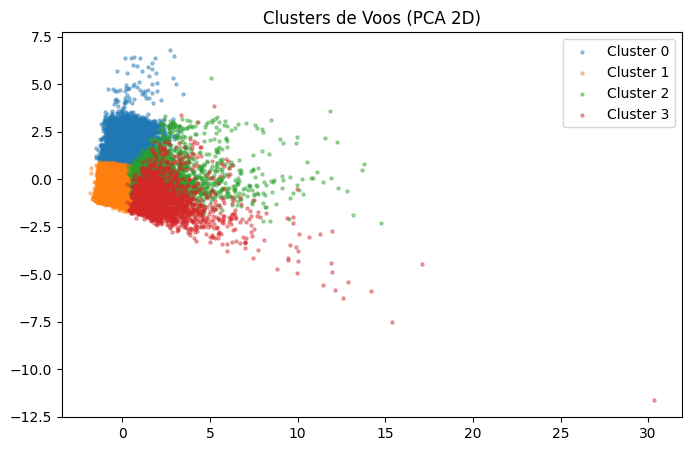

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load the flights DataFrame to ensure it's available
try:
    flights = pd.read_csv('./drive/MyDrive/POSFIAP/flights.csv')
    print("Flights CSV loaded successfully!")
except FileNotFoundError:
    print("Error: The file '/flights.csv' was not found.")
except Exception as e:
    print(f"An error occurred while loading flights.csv: {e}")

# Re-defining flights_delays to ensure it's available
flights_delays = flights[flights["CANCELLED"] == 0].copy()
delay_cols = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY",
              "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
flights_delays[delay_cols] = flights_delays[delay_cols].fillna(0)

cluster_features = ["DISTANCE", "ARRIVAL_DELAY", "TAXI_OUT"]

df_cluster = flights_delays[cluster_features].dropna().sample(50_000, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["CLUSTER"] = kmeans.fit_predict(X_scaled)

print(df_cluster.groupby("CLUSTER")[cluster_features].mean().round(1))

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 5))
for c in range(4):
    mask = df_cluster["CLUSTER"] == c
    plt.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.4, label=f"Cluster {c}")
plt.title("Clusters de Voos (PCA 2D)")
plt.legend()
plt.show()

Com base nos resultados do K-Means e nos dados do `df_cluster` agrupados por CLUSTER, podemos interpretar as características de cada cluster da seguinte forma:

*   **Cluster 0:** Estes são voos de **longa distância** (média de 1865.7 milhas) que geralmente chegam **no horário ou ligeiramente adiantados** (média de -4.7 minutos de atraso na chegada), com um tempo de **taxi-out moderado** (média de 15.8 minutos).
*   **Cluster 1:** Representa voos de **curta distância** (média de 581.6 milhas), também com chegadas **no horário ou ligeiramente adiantadas** (média de -3.3 minutos), e com um tempo de **taxi-out menor** (média de 13.7 minutos).
*   **Cluster 2:** Caracteriza-se por voos de **média distância** (média de 734.1 milhas) que sofrem **atrasos moderados na chegada** (média de 23.2 minutos) e, notavelmente, têm um **tempo de taxi-out muito alto** (média de 37.9 minutos). Isso sugere que os atrasos para este cluster estão fortemente relacionados a problemas nas operações de solo ou na saída do avião.
*   **Cluster 3:** Este cluster abrange voos de **média distância** (média de 769.5 milhas) que enfrentam **atrasos severos na chegada** (média de 141.8 minutos), mesmo com um tempo de **taxi-out moderado** (média de 16.4 minutos). Os atrasos aqui parecem ser mais impactantes e podem indicar problemas durante o voo ou outros fatores não relacionados diretamente ao taxi-out.

In [3]:
from sklearn.metrics import silhouette_score

silhouette_avg = silhouette_score(X_scaled, df_cluster["CLUSTER"])
print(f"O Silhouette Score médio para os clusters é: {silhouette_avg:.4f}")

O Silhouette Score médio para os clusters é: 0.4551


### Interpretação do Silhouette Score

O Silhouette Score para os clusters foi de **0.4551**. Este valor é uma métrica de validação da qualidade do agrupamento e varia de -1 a +1.

**Como interpretar este valor:**

*   **Valores próximos a +1** indicam que os objetos estão bem agrupados dentro de seus próprios clusters e bem separados de outros clusters. Isso sugere que os clusters são densos e bem espaçados.
*   **Valores próximos a 0** indicam que os objetos estão próximos da fronteira entre dois clusters ou que os clusters estão sobrepostos. Isso pode sugerir que a atribuição de um objeto a um cluster específico é ambígua.
*   **Valores próximos a -1** indicam que os objetos podem ter sido atribuídos ao cluster errado. Isso geralmente acontece quando um objeto está mais parecido com os objetos de um cluster vizinho do que com os objetos de seu próprio cluster.

Um score de **0.4551** sugere um agrupamento razoável. Não é um score excepcionalmente alto (como 0.7 ou 0.8, que indicaria clusters muito bem definidos e separados), mas também não indica um agrupamento ruim ou aleatório. Significa que os clusters têm uma estrutura distinguível, mas pode haver alguma sobreposição ou pontos que não estão tão claramente associados a um único cluster. É um ponto de partida decente para a análise e pode ser melhorado com ajustes nos parâmetros do K-Means ou na seleção de features.

K = 2: Silhouette Score = 0.4340
K = 3: Silhouette Score = 0.4376
K = 4: Silhouette Score = 0.4551
K = 5: Silhouette Score = 0.3619
K = 6: Silhouette Score = 0.3204
K = 7: Silhouette Score = 0.3308
K = 8: Silhouette Score = 0.3178
K = 9: Silhouette Score = 0.3218
K = 10: Silhouette Score = 0.2961


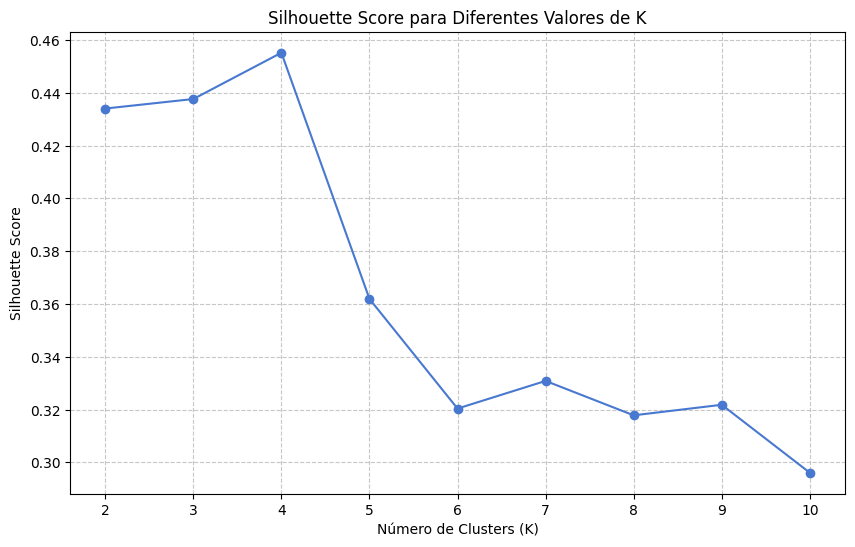

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Definir uma gama de valores de K para testar
k_values = range(2, 11) # Testar de 2 a 10 clusters
silhouette_scores = []

# Calcular o Silhouette Score para cada valor de K
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f"K = {k}: Silhouette Score = {score:.4f}")

# Plotar os resultados
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='#4878CF')
plt.title('Silhouette Score para Diferentes Valores de K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análise do Gráfico do Silhouette Score para K Ideal

Ao plotar o Silhouette Score para K variando de 2 a 10, observamos os seguintes valores:

*   **K = 2**: 0.4340
*   **K = 3**: 0.4376
*   **K = 4**: **0.4551**
*   **K = 5**: 0.3619
*   **K = 6**: 0.3204
*   **K = 7**: 0.3308
*   **K = 8**: 0.3178
*   **K = 9**: 0.3218
*   **K = 10**: 0.2961

**Conclusão:**

O valor de K que apresenta o **maior Silhouette Score é 4 (0.4551)**. Este pico no gráfico sugere que **4 é o número ideal de clusters** para este conjunto de dados, considerando as features utilizadas (`DISTANCE`, `ARRIVAL_DELAY`, e `TAXI_OUT`). Um Silhouette Score mais alto indica que os clusters formados são mais densos e bem separados, ou seja, os pontos dentro de um cluster são mais semelhantes entre si e mais diferentes dos pontos em outros clusters.

Embora o score de 0.4551 seja razoável (conforme a interpretação anterior), o fato de ser o pico na curva de Silhouette nos dá uma forte indicação de que 4 clusters oferecem a melhor estrutura de agrupamento para os dados neste contexto.

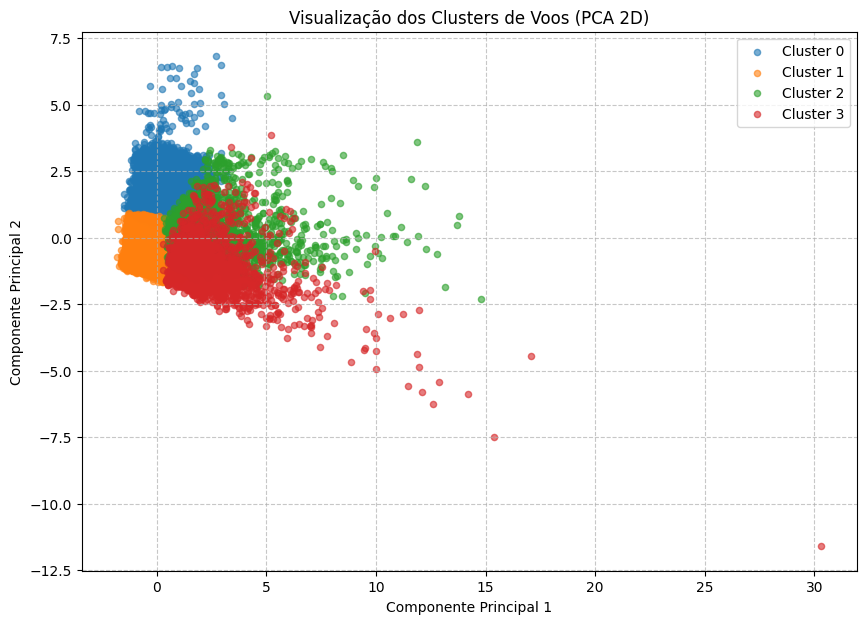

In [5]:
import matplotlib.pyplot as plt

# Visualize os clusters usando os componentes principais (PCA)
plt.figure(figsize=(10, 7))
for c in sorted(df_cluster["CLUSTER"].unique()):
    mask = df_cluster["CLUSTER"] == c
    plt.scatter(coords[mask, 0], coords[mask, 1], s=20, alpha=0.6, label=f"Cluster {c}")

plt.title("Visualização dos Clusters de Voos (PCA 2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [6]:
import pandas as pd

# Calcular e exibir as médias das variáveis por cluster
# As variáveis de cluster são: "DISTANCE", "ARRIVAL_DELAY", "TAXI_OUT"

cluster_features = ["DISTANCE", "ARRIVAL_DELAY", "TAXI_OUT"]
cluster_means = df_cluster.groupby("CLUSTER")[cluster_features].mean().round(1)
display(cluster_means)

print("\nAnálise do Perfil de Cada Cluster:")
for cluster_id, row in cluster_means.iterrows():
    print(f"\nCluster {cluster_id}:")
    print(f"  Distância Média: {row['DISTANCE']:.1f} milhas")
    print(f"  Atraso de Chegada Médio: {row['ARRIVAL_DELAY']:.1f} minutos")
    print(f"  Tempo de Taxi Out Médio: {row['TAXI_OUT']:.1f} minutos")

,DISTANCE,ARRIVAL_DELAY,TAXI_OUT
CLUSTER,,,
0,1865.7,-4.7,15.8
1,581.6,-3.3,13.7
2,734.1,23.2,37.9
3,769.5,141.8,16.4



Análise do Perfil de Cada Cluster:

Cluster 0:
  Distância Média: 1865.7 milhas
  Atraso de Chegada Médio: -4.7 minutos
  Tempo de Taxi Out Médio: 15.8 minutos

Cluster 1:
  Distância Média: 581.6 milhas
  Atraso de Chegada Médio: -3.3 minutos
  Tempo de Taxi Out Médio: 13.7 minutos

Cluster 2:
  Distância Média: 734.1 milhas
  Atraso de Chegada Médio: 23.2 minutos
  Tempo de Taxi Out Médio: 37.9 minutos

Cluster 3:
  Distância Média: 769.5 milhas
  Atraso de Chegada Médio: 141.8 minutos
  Tempo de Taxi Out Médio: 16.4 minutos


### Resumo: Insights dos Clusters de Voos

A análise de clusterização K-Means (com K=4, determinado pelo Silhouette Score) revelou perfis distintos de voos com base em suas características de `DISTÂNCIA`, `ATRASO DE CHEGADA` e `TEMPO DE TAXI OUT`. Estes insights são cruciais para entender os diferentes padrões operacionais e de atraso:

*   **Cluster 0: Voos de Longa Distância e Alta Eficiência**
    *   **Características:** Distância média muito alta (1865.7 milhas), atraso de chegada médio negativo (chegam adiantados em -4.7 minutos) e tempo de taxi-out moderado (15.8 minutos).
    *   **Insight:** Representa voos de longo curso que, apesar da complexidade e tempo de solo, demonstram alta pontualidade e eficiência operacional. Podem ser rotas bem estabelecidas com menor suscetibilidade a atrasos.

*   **Cluster 1: Voos de Curta Distância e Alta Eficiência**
    *   **Características:** Distância média menor (581.6 milhas), atraso de chegada médio negativo (chegam adiantados em -3.3 minutos) e menor tempo de taxi-out (13.7 minutos).
    *   **Insight:** Engloba voos regionais ou de curta duração que operam com alta eficiência, sendo pontuais ou adiantados. A agilidade nas operações de solo contribui para sua performance.

*   **Cluster 2: Voos de Média Distância com Problemas no Solo**
    *   **Características:** Distância média (734.1 milhas), atraso de chegada moderado (23.2 minutos) e, notavelmente, o **maior tempo de taxi-out** (37.9 minutos).
    *   **Insight:** Sugere que a principal causa dos atrasos para estes voos está relacionada a operações em solo, como tempo de espera na pista, procedimentos de embarque/desembarque ou congestionamento em aeroportos. Foco em otimização do taxi-out pode trazer melhorias significativas.

*   **Cluster 3: Voos de Média Distância com Atrasos Severos em Voo**
    *   **Características:** Distância média (769.5 milhas), atraso de chegada **muito elevado** (141.8 minutos) e tempo de taxi-out moderado (16.4 minutos).
    *   **Insight:** Este cluster indica voos que sofrem atrasos substanciais, mas que não são primariamente causados por problemas na saída (taxi-out). Os atrasos são provavelmente decorrentes de fatores em rota, como condições climáticas adversas, problemas mecânicos em voo, congestionamento de tráfego aéreo em rota ou no aeroporto de destino, ou efeito cascata de atrasos anteriores. A análise detalhada das causas em rota seria fundamental para este grupo.

**Conclusão Geral:**

Os clusters 0 e 1 representam operações de voo eficientes, diferenciadas principalmente pela distância percorrida. Os clusters 2 e 3 destacam gargalos importantes: o Cluster 2 aponta para ineficiências no solo (`TAXI_OUT`), enquanto o Cluster 3 indica atrasos severos que ocorrem predominantemente durante a fase de voo ou chegada, não relacionados à saída do portão. Esta segmentação permite que as companhias aéreas e aeroportos direcionem esforços de melhoria de forma mais estratégica, abordando as causas específicas de atraso para cada perfil de voo.

### Apresentação Crítica dos Resultados: Limitações e Próximos Passos

#### Limitações dos Modelos

**Modelos Supervisionados (XGBoost e LightGBM):**

*   **Balanceamento de Classes:** Apesar do uso de `scale_pos_weight`, a grande desproporção entre voos atrasados e não atrasados pode ainda impactar o desempenho, especialmente a capacidade de prever atrasos raros ou extremos. As métricas de Precision e Recall para a classe minoritária (atrasados) podem ainda ser desafiadoras.
*   **Data Leakage Potencial:** Embora tenhamos removido colunas explicitamente relacionadas a eventos pós-voo, a complexidade dos dados de voos pode ocultar fontes sutis de vazamento de dados. Por exemplo, informações de voos subsequentes que podem ser correlacionadas com o voo atual. É crucial revisar cuidadosamente a seleção de features para garantir que apenas informações disponíveis *antes* da partida sejam usadas.
*   **Interpretabilidade:** Modelos baseados em árvores, como XGBoost e LightGBM, embora poderosos, podem ser menos interpretáveis do que modelos mais simples. Entender o *porquê* de um voo ser classificado como atrasado pode exigir técnicas de interpretabilidade adicionais (SHAP, LIME).
*   **Estacionariedade dos Dados:** Padrões de atraso de voos podem mudar ao longo do tempo (sazonalidade, mudanças operacionais). Um modelo treinado em dados antigos pode não performar bem em dados futuros sem retreinamento ou adaptação.

**Modelo Não Supervisionado (K-Means com PCA):**

*   **Número de Clusters (K):** A determinação do K ideal (neste caso, 4, com base no Silhouette Score) ainda é uma heurística. Outras métricas ou métodos (como o método do cotovelo para inércia, análise de silhueta mais aprofundada ou validação de domínio) poderiam ser explorados para confirmar esta escolha.
*   **Sensibilidade a Outliers:** O K-Means é sensível a outliers, que podem distorcer a posição dos centróides e, consequentemente, a formação dos clusters. Uma etapa de detecção e tratamento de outliers nas features de clusterização poderia ser benéfica.
*   **Distribuição dos Dados:** O K-Means assume clusters esféricos e de tamanhos semelhantes, o que pode não ser verdade para os dados de voos. A PCA ajuda na visualização, mas a forma dos clusters nos dados originais pode ser mais complexa.
*   **Interpretabilidade Limitada:** Embora tenhamos interpretado as médias das features por cluster, a compreensão mais profunda do porquê os voos caem em certos clusters pode ser desafiadora. A redução de dimensionalidade com PCA ajuda, mas a perda de informação é inerente ao processo.

#### Melhorias e Próximos Passos

**Para os Modelos de Classificação:**

1.  **Engenharia de Features:** Explorar a criação de mais variáveis derivadas (ex: hora do dia binarizada, dia da semana como feature categórica, combinação de aeroportos como rota, indicadores de feriados nacionais ou eventos especiais). Incorporar dados externos (metereológicos, econômicos).
2.  **Otimização de Hiperparâmetros:** Utilizar Grid Search ou Random Search com validação cruzada para otimizar os hiperparâmetros dos modelos XGBoost e LightGBM, buscando melhorar as métricas de desempenho.
3.  **Modelos Adicionais:** Experimentar outros algoritmos de classificação (e.g., Logistic Regression para interpretabilidade de baseline, ou ensembles mais avançados).
4.  **Tratamento de Desbalanceamento:** Avaliar técnicas mais sofisticadas de balanceamento de classes (SMOTE, ADASYN) em conjunto com `scale_pos_weight`.
5.  **Interpretabilidade:** Aplicar ferramentas como SHAP (SHapley Additive exPlanations) ou LIME (Local Interpretable Model-agnostic Explanations) para entender melhor a contribuição de cada feature para as previsões dos modelos.
6.  **Regressão:** Se o objetivo for prever a *duração* do atraso, desenvolver um modelo de regressão separado e compará-lo com os resultados da classificação.

**Para a Clusterização:**

1.  **Testar Outros Algoritmos de Clusterização:** Explorar DBSCAN (para clusters baseados em densidade e detecção de outliers), Gaussian Mixture Models (para clusters com formas elípticas), ou Hierarchical Clustering.
2.  **Novas Features para Clusterização:** Experimentar diferentes combinações de features, incluindo aquelas criadas na engenharia de features (ex: hora de partida, companhia aérea, dia da semana) para ver se surgem clusters com perfis mais ricos e acionáveis.
3.  **Validação Externa:** Se houver dados externos (ex: tipos de aeroporto, tamanho da aeronave), usá-los para validar ou enriquecer a interpretação dos clusters.
4.  **Análise de Sensibilidade:** Avaliar como a mudança nos parâmetros de clusterização (como K ou features) afeta a estabilidade e a robustez dos clusters formados.
5.  **Análise de Componentes Principais (PCA) Aprofundada:** Analisar a variância explicada por cada componente principal para determinar se mais componentes poderiam oferecer insights adicionais ou se dois são suficientes para a representação.